O objetivo desse experimento é reproduzir os resultados do paper:

RASHT-BEHESHT, Majid; HUBER, Christian; SHUKLA, Khemraj; KARNIADAKIS, George Em. \
**Physics-informed neural networks (PINNs) for wave propagation and full waveform inversions**. \
*Journal of Geophysical Research: Solid Earth*, v. 127, n. 5, e2021JB023120, 2022. DOI: 10.1029/2021JB023120.

### Importando bibliotecas

In [57]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

import deepwave
from deepwave import scalar

import scipy.interpolate as interpolate

In [40]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Carregando os dados

In [41]:
# modelo de velocidade
data_vel = '/home/al.leticia.ferreira/piml-pub/proj-01/data/deepwave-lab-main_forward_marmousi/deepwave-lab-main/testmodel/marmousi_vp.bin'
# densidade do meio
data_rho = '/home/al.leticia.ferreira/piml-pub/proj-01/data/deepwave-lab-main_forward_marmousi/deepwave-lab-main/testmodel/marmousi_rho.bin'

velocidade máxima =  5500.0
velocidade mínima =  1500.0


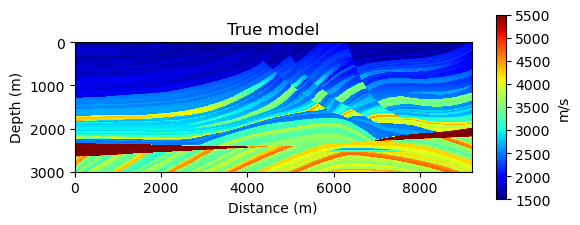

In [42]:
# usando alguns parâmetros já definidos em testes anteriores:
nz = 751 # profundidade do modelo (vertical)
dz = 4.0 # espaçamento da malha no eixo z
oz = 0.0
ny = 2301 # distânia do modelo (horizontal)
dy = 4.0
oy = 0.0

f = open(data_vel) # reading velocity model
vel = np.fromfile(f, dtype='f4', count=nz*ny) # nz*ny é a dimensão do modelo
vel = vel.reshape([nz, ny],order='F') # reshape do modelo
f.close()

# construir os eixos z (vertical) e y (horizontal)
z_values = np.arange(oz, oz + nz * dz, dz)
y_values = np.arange(oy, oy + ny * dy, dy)

# obter os valores máximo e mínimo da velocidade do modelo:
max_value = np.max(vel)
min_value = np.min(vel)
print('velocidade máxima = ', max_value)
print('velocidade mínima = ', min_value)

# plotar imagem
plt.imshow(vel, cmap='jet', extent=[y_values[0], y_values[-1], z_values[-1], z_values[0]],interpolation='none' )

# ajustar os limites de velocidade do plot
plt.clim(vmin=min_value, vmax=max_value)

# barra lateral com cores
cbar = plt.colorbar(shrink=0.5)
cbar.ax.tick_params(labelsize=10)
tick_values = np.arange(min_value, max_value+0.1,500)
cbar.set_ticks(tick_values)

# título e legendas
plt.title('True model')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
cbar.set_label('m/s')

plt.show()

### Definindo a geometria de aquisição

In [43]:
# aquisição de parametros para modelagem sismica com o deepwave
# são os mesmos parâmetros do example_acoustic_modeling.ipynb

dx = 4.0 # grid spacing
dt = 0.004 # discretização do tempo
nt = 750 # quantidade de amostras temporais
peak_freq = 25 # frequência da wavelet de Ricker
peak_time = 1.5 / peak_freq # pico da wavelet (instante que a wavelet atingue a amplitude máxima)
num_dims = 2 #2D modeling

# Parâmetros da geometria de aquisição:
num_shots = 3 # serão simuladas 3 explosões
num_sources_per_shot = 1 # cada shot possui apenas uma fonte
num_receivers_per_shot = 384 # cada tiro é registrado por 384 geofones
source_spacing = 1000 # espaçamentro entre os tiros
receiver_spacing = 6 # espaçamentro dos receptores/geofones
first_source = 150 # primeiro shot (a posição horizontal é 150 * 4 m)
source_depth = 2 # profundidade da fonte (vertical: 2 * 4 m)
first_receiver = 0 # posição do primeiro receptor/geofone (horizontal)
receiver_depth = 2 # profundidade dos receptores/geofones (vertical: 2 * 4 m)


# source_locations
source_locations = torch.zeros(num_shots,num_sources_per_shot,2, dtype=torch.long, device=device)
source_locations[..., 1] = source_depth # profundidade em que cada fonte é posicionada
source_locations[:, 0, 0] = torch.arange(num_shots)*source_spacing+first_source # posicionamento das fontes

# receiver_locations
receiver_locations = torch.zeros(num_shots,num_receivers_per_shot, 2, dtype=torch.long, device=device) # array de zeros

receiver_locations[..., 1] = receiver_depth # profundidade dos receptores/geofones
receiver_locations[:, :, 0] = (torch.arange(num_receivers_per_shot)*receiver_spacing + first_receiver).repeat(num_shots, 1) # posicionamento dos receptores

# source_amplitudes (Ricker)
source_amplitudes = deepwave.wavelets.ricker(peak_freq, nt, dt, peak_time).repeat(num_shots,num_sources_per_shot, 1).to(device)

**Wavelet de Ricker:**

É uma função que corresponde à segunda derivada de uma função gaussiana.

No domínio do tempo, a equação é descrita como:
$$
\psi(t) = (1-2 \pi² f_{p}^{2}t²)e^{- \pi² f_{p}² t^2}
$$
Onde:
- $t$: tempo
- $f_{p}$: frequência de pico da wavelet

**Forma**: Possui um pico central proeminente e dois lóbulos laterais menores.

**Parâmetro Único**: É modelada de forma exclusiva utilizando um único parâmetro, a sua frequência de pico.

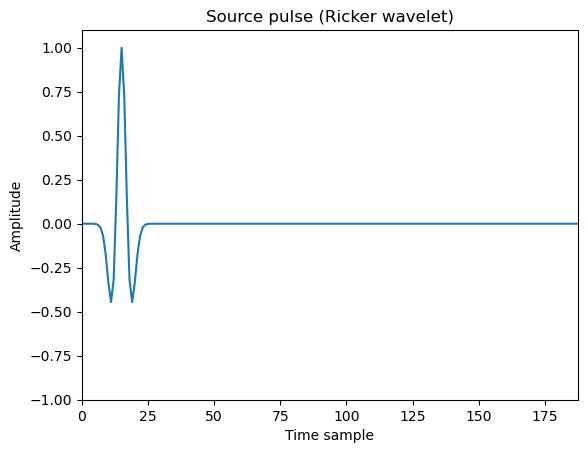

In [44]:
plt.plot(source_amplitudes.cpu().T[:, 0, 0])
plt.ylim(-1, 1+0.1)
plt.xlim(0, nt/4)
plt.title('Source pulse (Ricker wavelet)')
plt.ylabel('Amplitude')
plt.xlabel('Time sample')
plt.show()

### Modelagem do campo de onda

In [45]:
# transformando o modelo em tensor:
model_true = torch.tensor(vel, dtype=torch.float32, device=device).T
max_true = max_value

In [46]:
# Wavefield modeling
out = scalar(model_true, dx, dt, max_vel=float(max_true),
              source_amplitudes=source_amplitudes,
              source_locations=source_locations,
              receiver_locations=receiver_locations,
              accuracy=8,
              pml_freq=peak_freq,
              pml_width=[30,30,30,30])
data=out[-1]

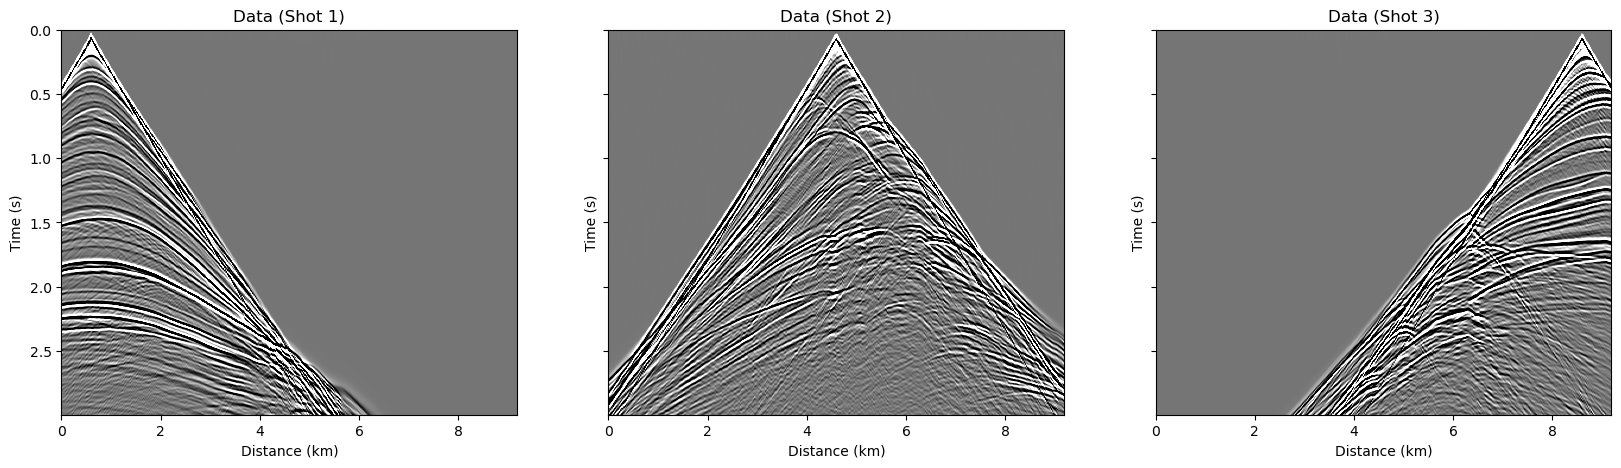

In [47]:
# vetor do tempo (discretizado)
time = np.arange(nt) * dt

# constantes de conversão:
km_to_m = 1000 # km/s para m/s
m_to_km = 1 / km_to_m # m/s para km/s# Wavefield modeling
out = scalar(model_true,
             dx, dt, 
             max_vel=float(max_true),
             source_amplitudes=source_amplitudes,
             source_locations=source_locations,
             receiver_locations=receiver_locations,
             accuracy=8,
             pml_freq=peak_freq, # Perfectly Matched Layer (absorção das ondas nas bordas)
             pml_width=[30, 30, 30, 30])

data=out[-1]

# vetor de distância discretizado
distance = np.arange(num_receivers_per_shot) * receiver_spacing * dx + first_receiver * dx
distance = distance * m_to_km # distância em quilômetros

vmin, vmax = torch.quantile(data, torch.tensor([0.05, 0.95]).to(device))

# criando plots
fig, ax = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for i in range(num_shots):
    ax[i].imshow(data[i, :].cpu().T,
                 aspect='auto',
                 cmap='gray',
                 vmin=vmin,
                 vmax=vmax,
                 extent=[distance[0], distance[-1], time[-1], time[0]]
                )
    ax[i].set_title(f'Data (Shot {i+1})')
    ax[i].set_xlabel('Distance (km)')
    ax[i].set_ylabel('Time (s)')

#plt.tight_layout()
plt.show()

### Reprodução do paper usando pyTorch

In [48]:
import torch.nn as nn
from torch.optim import Adam

**Definição dos parâmetros do domínio da PINN**

In [49]:
# ponto superior esquerdo do domínio
oz = 0.0
oy = 0.0

nz = 751 # vertical
ny = 2301 # horizontal

# fatores de discretização
dz = 4.0
dy = 4.0

# parâmetros para o SPECFEM:
az_spec = nz * dz / 1000 # km
ay_spec = ny * dy / 1000 # km

n_abs = 30 # espessura da camada absorvente
n_absz, n_absy = n_abs, n_abs

pml = 30 # Perfectly Matched Layer (absorção das ondas nas bordas)

rho = 1.0

az = oz + nz * dz # largura do domínio PINN
ay = oy + ny * dy # profundidade do domínio PINN

t_m = nt * dt  # tempo total de treino PDE
t_st = 0.10  # tempo da 1ª condição inicial
t_s = 0.5  # janela total dos sismogramas usados
s_spec = 5e-5  # passo de tempo do SPECFEM

# snapshots de condições inicias
t01 = 0.10 # 1º snapshot de deslocamento
t02 = 0.30 # 2º snapshot
t_la = 2.0 # dado de teste

n_seis = num_receivers_per_shot # número de receptores/geofones

z0_s = receiver_depth # profundidade do primeiro receptor
zl_s = receiver_depth # profundidade do último receptor

Lz, Ly   = 3.0, 3.0 # fatores para normalização

n_event = num_shots # número de disparos

u_scl = 1.0 / data.abs().max().item() # escala de normalização para a saída

A **inicialização de Xavier** é usada para inicializar pesos que evitem que o sinal fique muito fraco (*vanishing gradient*) ou muito fortes (*exploding gradient*) nas camadas mais profundas.

In [50]:
# inicialização xavier
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

A entrada das redes serão normalizadas para [-1, 1] e ao longo do treinamento serão usadas como função de ativação $\sigma = \sin(\cdot)$ ou $\tanh(\cdot)$.
$$
X \rightarrow \frac{2X}{max(X)} -1
$$

In [51]:
LAYERS_PHI = [3, 30, 30, 30, 1]
LAYERS_ALPHA = [2, 50, 50, 50, 50, 50, 1]

#### Rede Neural para aprender a função $\phi (x, z, t)$:

In [52]:
class PhiNet(nn.Module):
    '''
    Rede neural para aproximar o potencial escalar ϕ.
    Input:
        Entradas:
            [x, z, t] (normalizada para [-1, 1])
            layers_phi: list com a quantidade de neurônios por layer [N0, N1, ...]
    '''
    def __init__(self, layers_phi=LAYERS_PHI):
        super().__init__()

        # definindo as layers ocultas com função de ativação tanh
        hidden_layers = [
            layer for i in range(len(layers_phi) - 2)
            for layer in (nn.Linear(layers_phi[i], layers_phi[i+1]),
            nn.Tanh())]
        
        output_layer = [nn.Linear(layers_phi[-2], layers_phi[-1])]

        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)
        
        # limites de normalização: [az/Lz, ay/Ly, t_m-t_st]
        ub = torch.tensor([az / Lz, ay / Ly, t_m - t_st], dtype=torch.float64).to(device)
        self.register_buffer("ub", ub) # armazenando parâmetros não treináveis

    def forward(self, xzt):
        # normalização para [-1, 1]
        x_norm = (2.0 * xzt) / self.ub - 1.0
        return self.net(x_norm)

#### Rede Neural para a velocidade $\alpha (x, z)$:


In [53]:
class AlphaNet(nn.Module):
    """
    Aproxima a velocidade da onda \alpha
    Entrada: [x, z]  (normalizada para [-1, 1])
    Camadas: [2, N1, N2, N3, N4, N5, 1]  (igual ao original)
    Saída confinada a uma caixa via smooth step.
    """
    def __init__(self, layers_alpha=LAYERS_ALPHA):
        super().__init__()

        hidden_layers = [
            layer for i in range(len(layers_alpha) - 2)
            for layer in (nn.Linear(layers_alpha[i], layers_alpha[i+1]),
            nn.Tanh())]
        
        output_layer = [nn.Linear(layers_alpha[-2], layers_alpha[-1])]

        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)
        
        ub0 = torch.tensor([az / Lz, ay / Ly], dtype=torch.float64).to(device)
        self.register_buffer("ub0", ub0)
    
        # limitas da caixa de inversão:
        
        # horizontal
        self.y_st = pml * dy / 1000
        self.y_fi = (ny - pml) * dy / 1000

        # vertical
        self.z_st = pml * dz / 1000
        self.z_fi = (nz - pml) * dz / 1000

        # lld: controla quão abrupta ou suave é a borda da caixa de inversão.
        self.lld = 1000.0

    def _alpha_star(self, xz):
        # normalização para [-1, 1]
        x_n = (2.0 * xz) / self.ub0 - 1.0
        return torch.tahn(self.net(x_n))

    def _box_mask(self, xv, zv):
        '''
        Suave indicador da caixa de inversão.
        Entrada:
            xv -> velocidade horizontal
            zv -> velocidade vertical
        '''
        # redefinindo porque o exemplo de modelagem acústica e o modelo do paper trocam essas variáveis
        Lx = Lz
        Lz = Ly

        lld = self.lld
        mask = (0.5 * (1 + torch.tanh(lld * (zv - self.z_st / Lz))) *
                0.5 * (1 + torch.tanh(lld * (-zv + self.z_fi / Lz))) *
                0.5 * (1 + torch.tanh(lld * (xv - self.x_st / Lx))) *
                0.5 * (1 + torch.tanh(lld * (-xv + self.x_fi / Lx))))
        return mask

    def forward(self, xv, zv):
        '''
        Retorna α(x, z).
        xv, zv : tensores coluna [N,1] com gradiente habilitado.
        '''
        xz = torch.cat([xv, zv], dim=1)
        a_star = self._alpha_star(xz)
        mask = self._box_mask(xv, zv)
        alpha = 3.0 + 2.0 * a_star * mask
        return alpha

**Velocidade verdadeira do modelo**

Será usada como ground truth para comparação durante o treinamento.

In [54]:
def alpha_true_fn(vel_model, xv, zv):
    # velocidade verdadeira para cada coordenada x, z
    return vel_model[xv, zv]

Definir malha de pontos para avaliação $K \times K$. 

O objetivo é poder usar posteriormente para fazer avaliações pontuais do resultado do modelo:

In [58]:
n_ini = 40 # K do grid
yy_np, zz_np = np.meshgrid(
    np.linspace(0, ay / Ly, n_ini), # horizontal
    np.linspace(0, az / Lz, n_ini) # vertical
)

yy0_np  = yy_np.reshape(-1, 1)
zz0_np  = zz_np.reshape(-1, 1)

def np2t(arr, requires_grad=False):
    """Converte numpy para tensor float64 no device correto."""
    return torch.tensor(arr, dtype=torch.float64, requires_grad=requires_grad).to(device)

#### Carregando dados com o SPECFEM